In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
generation = pd.read_csv(r"C:\Users\osman\Videos\AML_A_!\data\Plant_1_Generation_Data.csv")
weather = pd.read_csv(r"C:\Users\osman\Videos\AML_A_!\data\Plant_1_Weather_Sensor_Data.csv")
print("Generation shape:", generation.shape)
print("Weather shape:", weather.shape)

Generation shape: (68778, 7)
Weather shape: (3182, 6)


In [8]:
generation["DATE_TIME"] = pd.to_datetime(
    generation["DATE_TIME"],
    dayfirst=True
)

weather["DATE_TIME"] = pd.to_datetime(
    weather["DATE_TIME"]
)
print(generation["DATE_TIME"].head())
print(weather["DATE_TIME"].head())

0   2020-05-15
1   2020-05-15
2   2020-05-15
3   2020-05-15
4   2020-05-15
Name: DATE_TIME, dtype: datetime64[us]
0   2020-05-15 00:00:00
1   2020-05-15 00:15:00
2   2020-05-15 00:30:00
3   2020-05-15 00:45:00
4   2020-05-15 01:00:00
Name: DATE_TIME, dtype: datetime64[us]


In [ ]:
groupby("DATE_TIME")

In [11]:
plant_generation = (
    generation
    .groupby("DATE_TIME")["AC_POWER"]
    .sum()
    .reset_index()
)
print(plant_generation.head())
print(plant_generation.shape)

            DATE_TIME  AC_POWER
0 2020-05-15 00:00:00       0.0
1 2020-05-15 00:15:00       0.0
2 2020-05-15 00:30:00       0.0
3 2020-05-15 00:45:00       0.0
4 2020-05-15 01:00:00       0.0
(3158, 2)


In [12]:
plant_weather = weather[
    [
        "DATE_TIME",
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "IRRADIATION"
    ]
].copy()

In [13]:
plant_data = pd.merge(
    plant_generation,
    plant_weather,
    on="DATE_TIME",
    how="inner"
)
print(plant_data.head())
print(plant_data.shape)

            DATE_TIME  AC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0 2020-05-15 00:00:00       0.0            25.184316           22.857507   
1 2020-05-15 00:15:00       0.0            25.084589           22.761668   
2 2020-05-15 00:30:00       0.0            24.935753           22.592306   
3 2020-05-15 00:45:00       0.0            24.846130           22.360852   
4 2020-05-15 01:00:00       0.0            24.621525           22.165423   

   IRRADIATION  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          0.0  
(3157, 5)


In [14]:
print(
    "Duplicate timestamps:",
    plant_data["DATE_TIME"].duplicated().sum()
)

Duplicate timestamps: 0


In [15]:
print(
    "Duplicate timestamps:",
    plant_data["DATE_TIME"].duplicated().sum()
)

Duplicate timestamps: 0


In [16]:
plant_data = plant_data.sort_values("DATE_TIME")
plant_data = plant_data.reset_index(drop=True)

In [17]:

time_difference = plant_data["DATE_TIME"].diff()

print(time_difference.value_counts().head(10))

DATE_TIME
0 days 00:15:00    3146
0 days 00:30:00       3
0 days 03:00:00       1
0 days 01:00:00       1
0 days 04:15:00       1
0 days 09:00:00       1
0 days 01:45:00       1
0 days 08:00:00       1
0 days 00:45:00       1
Name: count, dtype: int64


In [18]:
plant_data = plant_data.set_index("DATE_TIME")
hourly_data = plant_data.resample("1h").mean()

In [19]:
print(hourly_data.isnull().sum())

hourly_data = hourly_data.dropna()

AC_POWER               20
AMBIENT_TEMPERATURE    20
MODULE_TEMPERATURE     20
IRRADIATION            20
dtype: int64


In [20]:
print("Hourly dataset shape:", hourly_data.shape)

Hourly dataset shape: (796, 4)


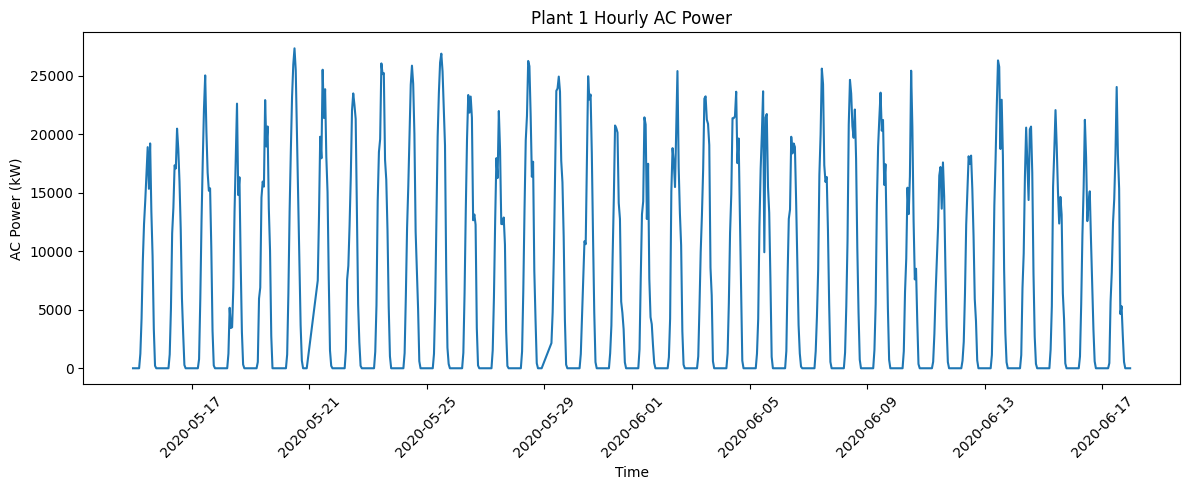

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_data.index,
    hourly_data["AC_POWER"]
)

plt.xlabel("Time")
plt.ylabel("AC Power (kW)")
plt.title("Plant 1 Hourly AC Power")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
print(hourly_data.head())
print(hourly_data.columns)

                     AC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
DATE_TIME                                                                
2020-05-15 00:00:00       0.0            25.012697           22.643083   
2020-05-15 01:00:00       0.0            24.667328           22.411960   
2020-05-15 02:00:00       0.0            24.986837           23.512072   
2020-05-15 03:00:00       0.0            24.954589           24.126433   
2020-05-15 04:00:00       0.0            24.276670           22.133106   

                     IRRADIATION  
DATE_TIME                         
2020-05-15 00:00:00          0.0  
2020-05-15 01:00:00          0.0  
2020-05-15 02:00:00          0.0  
2020-05-15 03:00:00          0.0  
2020-05-15 04:00:00          0.0  
Index(['AC_POWER', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'], dtype='str')


In [23]:
X = hourly_data[
    [
        "IRRADIATION",
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE"
    ]
].values

y = hourly_data["AC_POWER"].values
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (796, 3)
y shape: (796,)


In [24]:
split = int(0.8 * len(X))

X_train_raw = X[:split]
X_test_raw = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training samples:", len(X_train_raw))
print("Testing samples:", len(X_test_raw))

Training samples: 636
Testing samples: 160


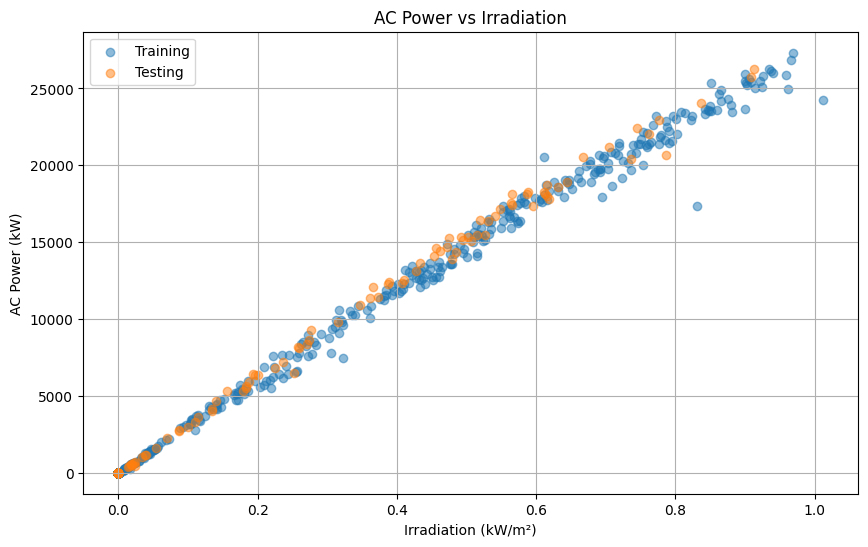

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_raw[:, 0], y_train, alpha=0.5, label="Training")
plt.scatter(X_test_raw[:, 0], y_test, alpha=0.5, label="Testing")
plt.xlabel("Irradiation (kW/m²)")
plt.ylabel("AC Power (kW)")
plt.title("AC Power vs Irradiation")
plt.legend()
plt.grid(True)
plt.show()

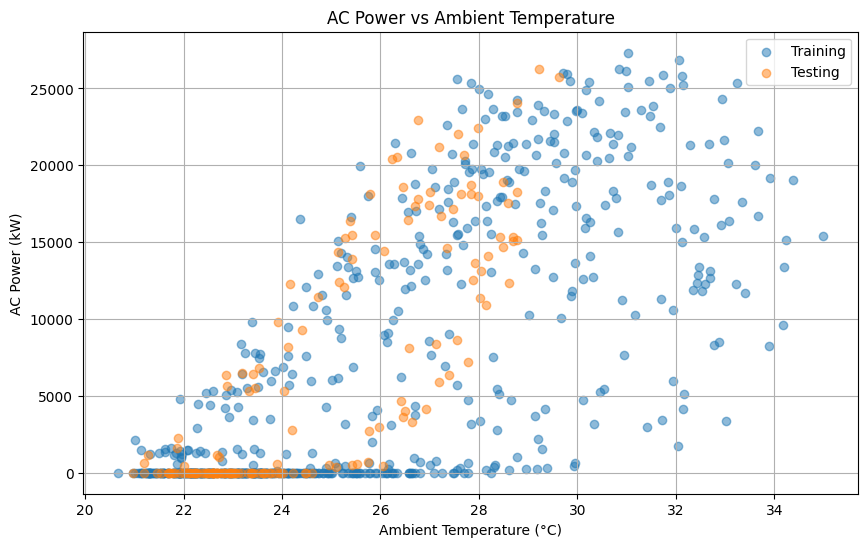

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_raw[:, 1], y_train, alpha=0.5, label="Training")
plt.scatter(X_test_raw[:, 1], y_test, alpha=0.5, label="Testing")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("AC Power (kW)")
plt.title("AC Power vs Ambient Temperature")
plt.legend()
plt.grid(True)
plt.show()

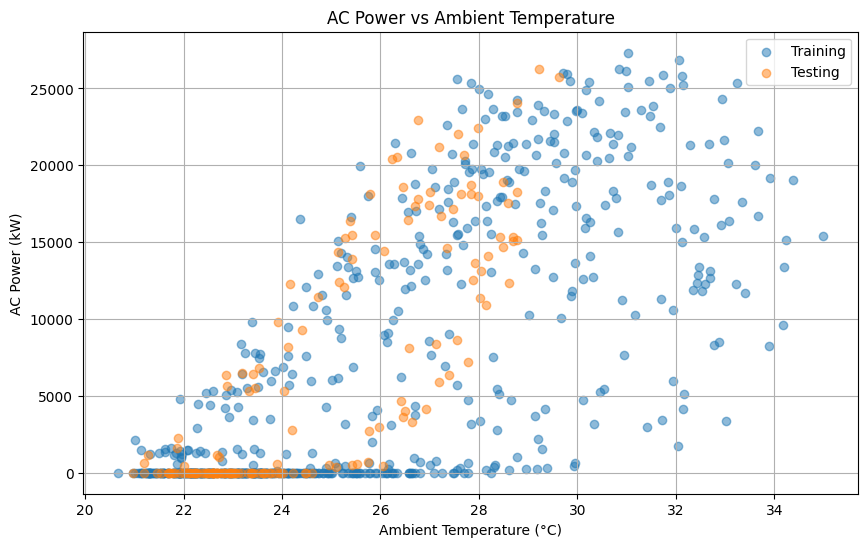

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_raw[:, 1], y_train, alpha=0.5, label="Training")
plt.scatter(X_test_raw[:, 1], y_test, alpha=0.5, label="Testing")
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("AC Power (kW)")
plt.title("AC Power vs Ambient Temperature")
plt.legend()
plt.grid(True)
plt.show()

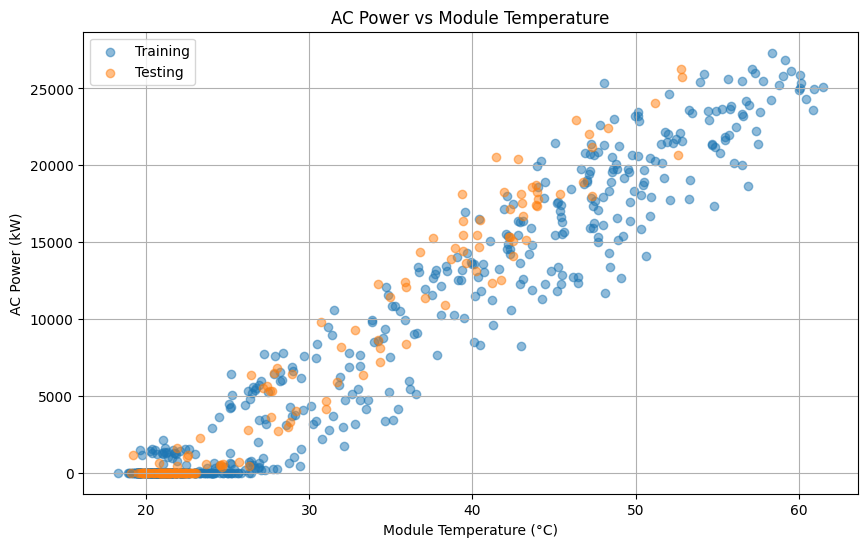

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_raw[:, 2], y_train, alpha=0.5, label="Training")
plt.scatter(X_test_raw[:, 2], y_test, alpha=0.5, label="Testing")
plt.xlabel("Module Temperature (°C)")
plt.ylabel("AC Power (kW)")
plt.title("AC Power vs Module Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
#Normal Equation
X_train = np.c_[
    np.ones(len(X_train_raw)),
    X_train_raw
]

X_test = np.c_[
    np.ones(len(X_test_raw)),
    X_test_raw
]
print(X_train.shape)
print(X_train[:3])

(636, 4)
[[ 1.          0.         25.01269695 22.64308323]
 [ 1.          0.         24.66732844 22.41195959]
 [ 1.          0.         24.98683673 23.51207183]]


In [30]:
theta_normal = (
    np.linalg.pinv(X_train.T @ X_train)
    @ X_train.T
    @ y_train
)

print("Theta:")
print(theta_normal)

Theta:
[-5.88761872e+02  2.79367160e+04  2.31577160e+01  6.76211514e+00]


In [31]:
#prediction
y_pred_normal = X_test @ theta_normal
print("Actual:")
print(y_test[:10])

print("\nPredicted:")
print(y_pred_normal[:10])

Actual:
[ 6422.15312505  9281.66696435 12063.0950893  16460.24598213
 17189.8758929  13628.22455355 17578.94598222 14656.35714288
  8647.66919643  3595.79866072]

Predicted:
[ 5556.2893237   7922.43043324 10465.37911596 14794.150407
 15622.94218496 12406.25389884 16109.28094855 13519.0577537
  7943.74180418  3412.61835738]


In [32]:
#Cost Fucntion
def compute_cost(X, y, theta):
    m = len(y)

    predictions = X @ theta

    errors = predictions - y

    cost = (1 / (2 * m)) * np.sum(errors ** 2)

    return cost
 

In [33]:
train_cost = compute_cost(
    X_train,
    y_train,
    theta_normal
)

print("Training Cost:", train_cost)

Training Cost: 162170.8712840399


In [34]:
#RMSE
rmse_normal = np.sqrt(
    np.mean(
        (y_test - y_pred_normal) ** 2
    )
)

print("Normal Equation RMSE:", rmse_normal)

Normal Equation RMSE: 658.0160601520339


In [35]:
# R^2
ss_res = np.sum(
    (y_test - y_pred_normal) ** 2
)

ss_tot = np.sum(
    (y_test - np.mean(y_test)) ** 2
)

r2_normal = 1 - (ss_res / ss_tot)

print("Normal Equation R²:", r2_normal)

Normal Equation R²: 0.992790453433975


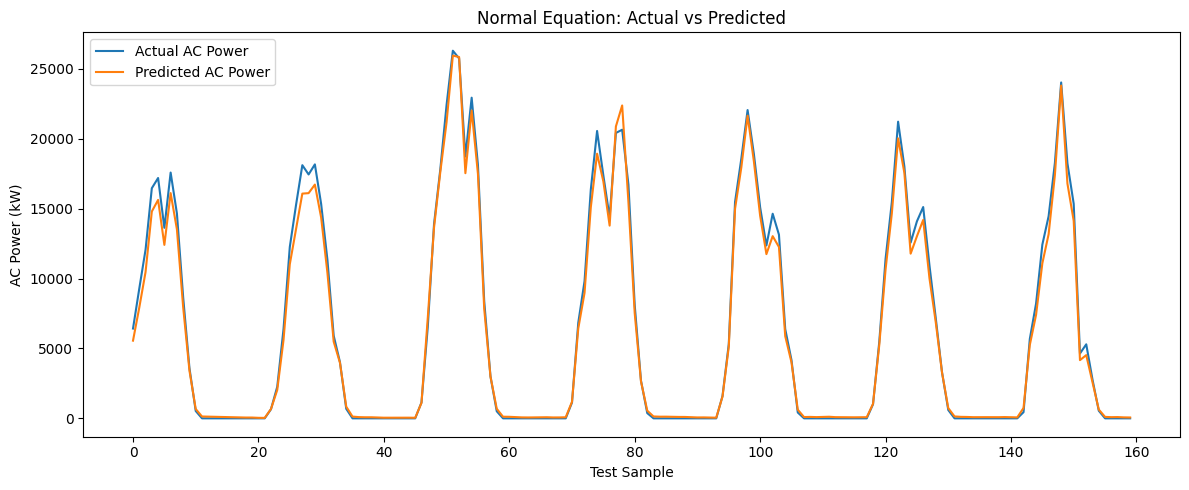

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test,
    label="Actual AC Power"
)

plt.plot(
    y_pred_normal,
    label="Predicted AC Power"
)

plt.xlabel("Test Sample")
plt.ylabel("AC Power (kW)")
plt.title("Normal Equation: Actual vs Predicted")

plt.legend()
plt.tight_layout()
plt.show()

In [37]:
#Batch Gradient Descent
mean = np.mean(X_train_raw, axis=0)
std = np.std(X_train_raw, axis=0)

X_train_scaled = (
    X_train_raw - mean
) / std

X_test_scaled = (
    X_test_raw - mean
) / std
print("Training mean:")
print(mean)

print("\nTraining standard deviation:")
print(std)

Training mean:
[ 0.23579453 25.78634201 31.59806141]

Training standard deviation:
[ 0.30143252  3.50305941 12.60639439]


In [38]:
#Adding intercept 
X_train_gd = np.c_[
    np.ones(len(X_train_scaled)),
    X_train_scaled
]

X_test_gd = np.c_[
    np.ones(len(X_test_scaled)),
    X_test_scaled
]

In [39]:
def batch_gradient_descent(X, y, alpha, iterations):

    m, n = X.shape

    theta = np.zeros(n)

    cost_history = []

    for i in range(iterations):

        predictions = X @ theta

        errors = predictions - y

        gradient = (1 / m) * (X.T @ errors)

        theta = theta - alpha * gradient

        cost = compute_cost(X, y, theta)

        cost_history.append(cost)

    return theta, cost_history

In [40]:
theta_bgd, cost_history = batch_gradient_descent(
    X_train_gd,
    y_train,
    alpha=0.01,
    iterations=5000
)

print(theta_bgd)

[6809.38554808 6236.77586459 -792.6599048  2973.13606562]


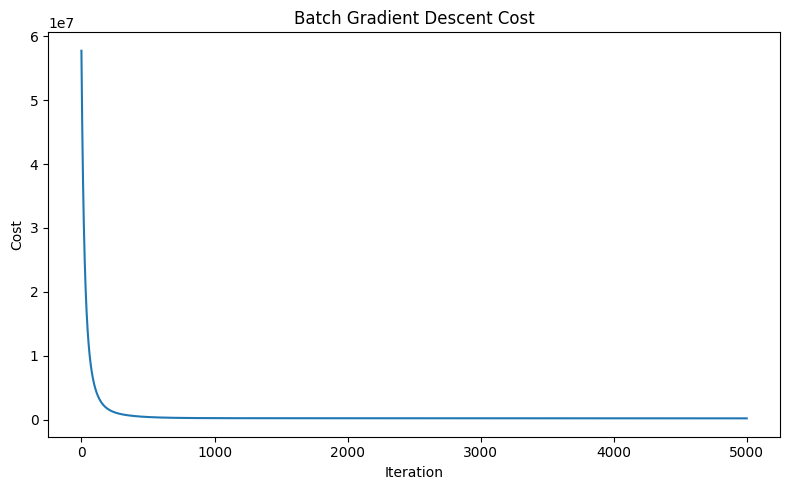

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Batch Gradient Descent Cost")

plt.tight_layout()
plt.show()

In [42]:
y_pred_bgd = X_test_gd @ theta_bgd

rmse_bgd = np.sqrt(
    np.mean(
        (y_test - y_pred_bgd) ** 2
    )
)

print("Batch GD RMSE:", rmse_bgd)

Batch GD RMSE: 792.2335678393767


In [43]:
ss_res = np.sum(
    (y_test - y_pred_bgd) ** 2
)

ss_tot = np.sum(
    (y_test - np.mean(y_test)) ** 2
)

r2_bgd = 1 - (ss_res / ss_tot)

print("Batch GD R²:", r2_bgd)

Batch GD R²: 0.9895493947324928


In [44]:
#Stochastic Gradient Descent
def stochastic_gradient_descent(
    X,
    y,
    alpha,
    epochs
):

    m, n = X.shape

    theta = np.zeros(n)

    cost_history = []

    for epoch in range(epochs):

        for i in range(m):

            xi = X[i]
            yi = y[i]

            prediction = xi @ theta

            error = prediction - yi

            gradient = xi * error

            theta = theta - alpha * gradient

        cost = compute_cost(
            X,
            y,
            theta
        )

        cost_history.append(cost)

    return theta, cost_history

In [45]:
theta_sgd, sgd_cost = stochastic_gradient_descent(
    X_train_gd,
    y_train,
    alpha=0.001,
    epochs=50
)

print(theta_sgd)

[6814.25542597 6000.76122753 -887.82470962 3290.71004655]


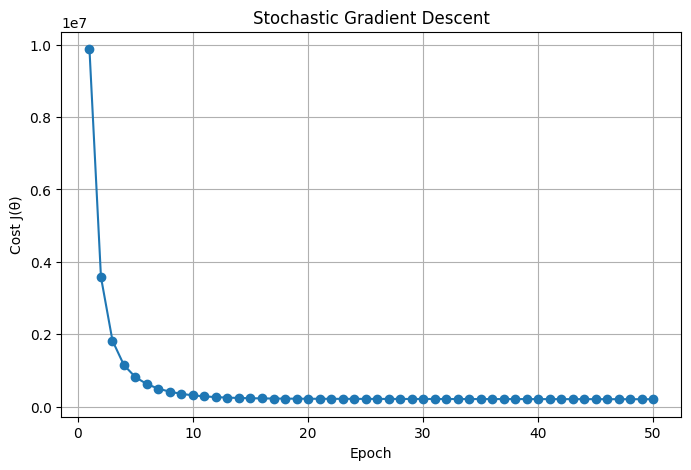

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(sgd_cost) + 1),
    sgd_cost,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Cost J(θ)")
plt.title("Stochastic Gradient Descent")
plt.grid(True)

plt.show()

In [47]:
y_pred_sgd = X_test_gd @ theta_sgd

rmse_sgd = np.sqrt(
    np.mean(
        (y_test - y_pred_sgd) ** 2
    )
)

print("SGD RMSE:", rmse_sgd)

SGD RMSE: 807.1946744679724


In [48]:
ss_res = np.sum(
    (y_test - y_pred_sgd) ** 2
)

ss_tot = np.sum(
    (y_test - np.mean(y_test)) ** 2
)

r2_sgd = 1 - (ss_res / ss_tot)

print("SGD R²:", r2_sgd)

SGD R²: 0.9891509542633536


In [49]:
results = pd.DataFrame({
    "Method": [
        "Normal Equation",
        "Batch Gradient Descent",
        "Stochastic Gradient Descent"
    ],

    "RMSE": [
        rmse_normal,
        rmse_bgd,
        rmse_sgd
    ],

    "R2": [
        r2_normal,
        r2_bgd,
        r2_sgd
    ]
})

print(results)

                        Method        RMSE        R2
0              Normal Equation  658.016060  0.992790
1       Batch Gradient Descent  792.233568  0.989549
2  Stochastic Gradient Descent  807.194674  0.989151


In [50]:
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 14.82,
    "longitude": 78.28,
    "start_date": "2020-05-15",
    "end_date": "2020-06-17",
    "hourly": "temperature_2m,shortwave_radiation",
    "timezone": "Asia/Kolkata"
}

response = requests.get(
    url,
    params=params
)

print("Status code:", response.status_code)

Status code: 200


In [51]:
data = response.json()
print(type(data))

<class 'dict'>


In [52]:
print(data.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])


In [53]:
print(data["hourly"].keys())

dict_keys(['time', 'temperature_2m', 'shortwave_radiation'])


In [54]:
public_weather = pd.DataFrame({
    "DATE_TIME": data["hourly"]["time"],

    "PUBLIC_TEMPERATURE":
        data["hourly"]["temperature_2m"],

    "PUBLIC_IRRADIATION":
        data["hourly"]["shortwave_radiation"]
})

In [55]:
print(public_weather.head())

          DATE_TIME  PUBLIC_TEMPERATURE  PUBLIC_IRRADIATION
0  2020-05-15T00:00                29.5                 0.0
1  2020-05-15T01:00                28.7                 0.0
2  2020-05-15T02:00                28.0                 0.0
3  2020-05-15T03:00                27.5                 0.0
4  2020-05-15T04:00                27.0                 0.0


In [56]:
public_weather["DATE_TIME"] = pd.to_datetime(
    public_weather["DATE_TIME"]
)

In [57]:
print(public_weather.dtypes)

DATE_TIME             datetime64[us]
PUBLIC_TEMPERATURE           float64
PUBLIC_IRRADIATION           float64
dtype: object


In [58]:
print("Rows:", len(public_weather))

print("\nStart:")
print(public_weather["DATE_TIME"].min())

print("\nEnd:")
print(public_weather["DATE_TIME"].max())

Rows: 816

Start:
2020-05-15 00:00:00

End:
2020-06-17 23:00:00


In [59]:
public_weather["PUBLIC_IRRADIATION"] = (
    public_weather["PUBLIC_IRRADIATION"] / 1000
)

In [60]:
hourly_data_public = hourly_data.reset_index()
print(hourly_data_public.head())

            DATE_TIME  AC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0 2020-05-15 00:00:00       0.0            25.012697           22.643083   
1 2020-05-15 01:00:00       0.0            24.667328           22.411960   
2 2020-05-15 02:00:00       0.0            24.986837           23.512072   
3 2020-05-15 03:00:00       0.0            24.954589           24.126433   
4 2020-05-15 04:00:00       0.0            24.276670           22.133106   

   IRRADIATION  
0          0.0  
1          0.0  
2          0.0  
3          0.0  
4          0.0  


In [61]:
comparison_data = pd.merge(
    hourly_data_public,
    public_weather,
    on="DATE_TIME",
    how="inner"
)
print(comparison_data.head())
print("\nShape:", comparison_data.shape)

            DATE_TIME  AC_POWER  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0 2020-05-15 00:00:00       0.0            25.012697           22.643083   
1 2020-05-15 01:00:00       0.0            24.667328           22.411960   
2 2020-05-15 02:00:00       0.0            24.986837           23.512072   
3 2020-05-15 03:00:00       0.0            24.954589           24.126433   
4 2020-05-15 04:00:00       0.0            24.276670           22.133106   

   IRRADIATION  PUBLIC_TEMPERATURE  PUBLIC_IRRADIATION  
0          0.0                29.5                 0.0  
1          0.0                28.7                 0.0  
2          0.0                28.0                 0.0  
3          0.0                27.5                 0.0  
4          0.0                27.0                 0.0  

Shape: (796, 7)


In [62]:
print(comparison_data.columns.tolist())

['DATE_TIME', 'AC_POWER', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'PUBLIC_TEMPERATURE', 'PUBLIC_IRRADIATION']


In [63]:
X_public = comparison_data[
    [
        "PUBLIC_IRRADIATION",
        "PUBLIC_TEMPERATURE"
    ]
].values

y_public = comparison_data["AC_POWER"].values

In [64]:

split_public = int(
    0.8 * len(X_public)
)

X_public_train_raw = X_public[:split_public]
X_public_test_raw = X_public[split_public:]

y_public_train = y_public[:split_public]
y_public_test = y_public[split_public:]

In [65]:
X_public_train = np.c_[
    np.ones(len(X_public_train_raw)),
    X_public_train_raw
]

X_public_test = np.c_[
    np.ones(len(X_public_test_raw)),
    X_public_test_raw
]

In [66]:
theta_public = (
    np.linalg.pinv(
        X_public_train.T @ X_public_train
    )
    @ X_public_train.T
    @ y_public_train
)

print("Public Weather Theta:")
print(theta_public)

Public Weather Theta:
[ 4414.01185745 26356.85150634  -127.98201057]


In [67]:
y_public_pred = (
    X_public_test @ theta_public
)

In [68]:
rmse_public = np.sqrt(
    np.mean(
        (y_public_test - y_public_pred) ** 2
    )
)

print(
    "Public Weather RMSE:",
    rmse_public
)

Public Weather RMSE: 3206.469622959832


In [69]:
ss_res_public = np.sum(
    (y_public_test - y_public_pred) ** 2
)

ss_tot_public = np.sum(
    (y_public_test - np.mean(y_public_test)) ** 2
)

r2_public = (
    1 -
    (ss_res_public / ss_tot_public)
)

print(
    "Public Weather R²:",
    r2_public
)

Public Weather R²: 0.8288057301675531


In [70]:
#How much prediction accuracy is lost when on-site irradiation and temperature sensors are
#replaced by free public weather data?
r2_loss = r2_normal - r2_public

relative_r2_loss = (
    (r2_normal - r2_public)
    / r2_normal
) * 100

print("R² loss:", r2_loss)
print(
    "Relative R² loss (%):",
    relative_r2_loss
)

R² loss: 0.16398472326642188
Relative R² loss (%): 16.517556418800474


In [71]:
rmse_increase = (
    (rmse_public - rmse_normal)
    / rmse_normal
) * 100

print(
    "RMSE increase (%):",
    rmse_increase
)

RMSE increase (%): 387.29352019447384


In [72]:
final_results = pd.DataFrame({
    "Model": [
        "On-site Sensor Data",
        "Public Weather Data"
    ],

    "RMSE": [
        rmse_normal,
        rmse_public
    ],

    "R2": [
        r2_normal,
        r2_public
    ]
})

print(final_results)

                 Model         RMSE        R2
0  On-site Sensor Data   658.016060  0.992790
1  Public Weather Data  3206.469623  0.828806


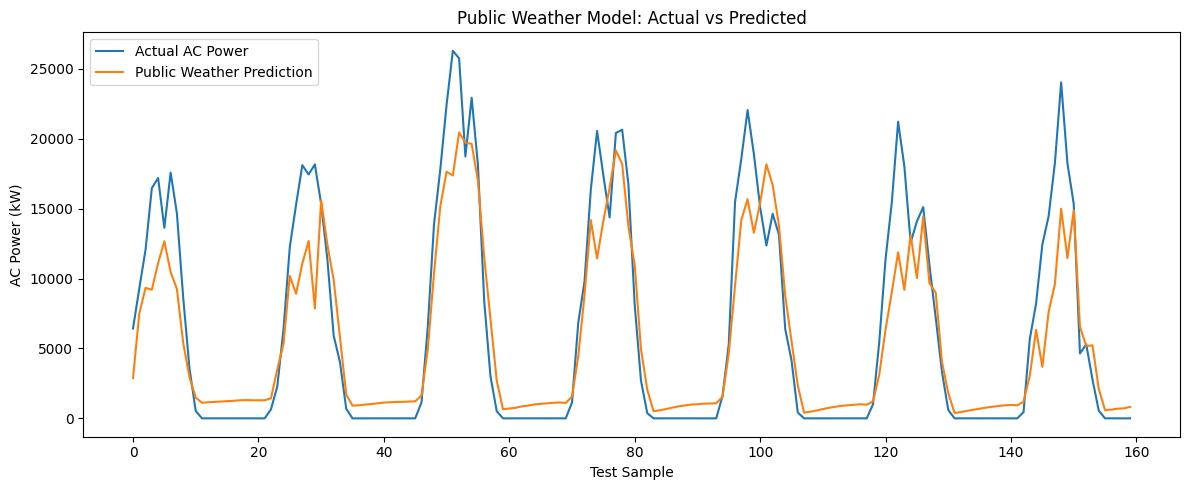

In [73]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_public_test,
    label="Actual AC Power"
)

plt.plot(
    y_public_pred,
    label="Public Weather Prediction"
)

plt.xlabel("Test Sample")
plt.ylabel("AC Power (kW)")
plt.title(
    "Public Weather Model: Actual vs Predicted"
)

plt.legend()
plt.tight_layout()
plt.show()

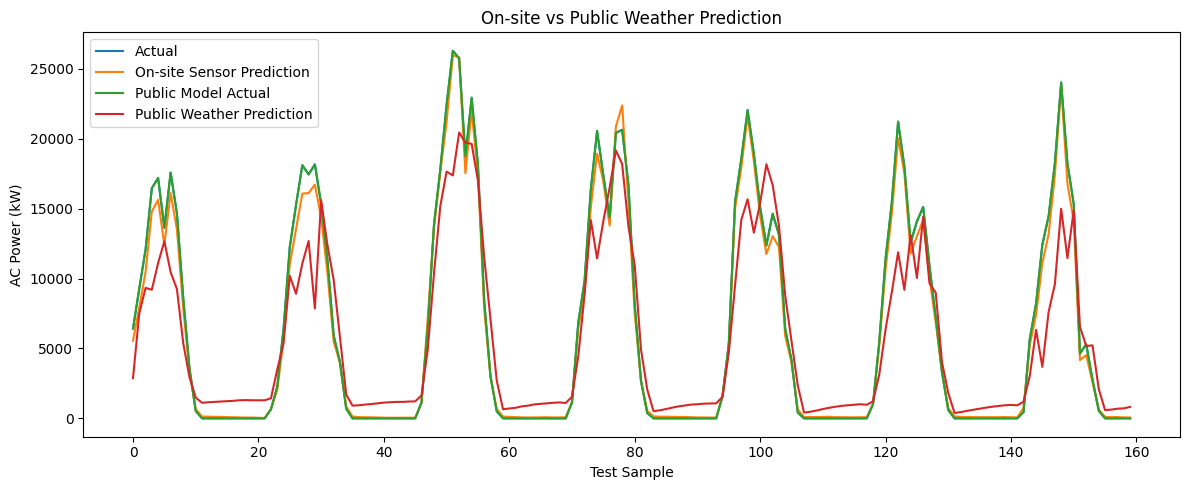

In [74]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test,
    label="Actual"
)

plt.plot(
    y_pred_normal,
    label="On-site Sensor Prediction"
)

plt.plot(
    y_public_test,
    label="Public Model Actual"
)

plt.plot(
    y_public_pred,
    label="Public Weather Prediction"
)

plt.xlabel("Test Sample")
plt.ylabel("AC Power (kW)")
plt.title("On-site vs Public Weather Prediction")

plt.legend()
plt.tight_layout()
plt.show()